# AI-Powered Resume Screening & Job Role Prediction
## ML Backend Pipeline — Scope Declaration

---

### In Scope
- Data inspection, cleaning, and NLP preprocessing
- TF-IDF feature engineering with a small comparison grid
- Training and comparing **4 classical ML models**: Logistic Regression, Multinomial Naive Bayes, Random Forest, Support Vector Machine
- Evaluation (accuracy, macro-F1, weighted-F1, precision, recall, confusion matrices)
- Model selection (winner = highest **macro-F1** on held-out validation set)
- Saving model artifacts via `joblib`
- A reusable `predict_job_role(text)` prediction function
- A rule-based `extract_skills(text)` skill extractor

### Out of Scope (not built here)
- Flask / FastAPI wrapper or any web server
- Web or mobile UI
- Deep learning / transformer models (BERT, RoBERTa, etc.)
- **External AI APIs** — no OpenAI, Gemini, Claude, or similar services are called anywhere in this notebook
- Database integration, authentication, containerization

> **Scope lock**: If any future contributor is tempted to add an external AI API call, refer to this cell first.

---
## Section 1 — Configuration
**All tunables live here.** Nothing is hardcoded deeper in the notebook.
Edit this cell before running to match your dataset.

In [1]:
# ============================================================
# SECTION 1: CONFIGURATION — Edit here, nowhere else
# ============================================================

import os

# ---------- Reproducibility ----------
RANDOM_STATE = 42  # Used in every stochastic step

# ---------- Dataset ----------
# Path to your CSV/Excel resume dataset.
# Set to None to auto-generate a small synthetic dataset for smoke-testing.
DATASET_PATH = 'resume_data_labeled.csv'  # Real dataset (9,544 resumes, 28 roles)

# Column names — set to None to enable heuristic auto-detection.
# Override these if auto-detection fails (it will tell you).
TEXT_COLUMN  = 'Resume_Text'  # Full raw resume text column
LABEL_COLUMN = 'job_role'     # Clean role label (28 categories)

# ---------- Data quality thresholds ----------
MIN_TOKEN_COUNT = 20   # Resumes with fewer tokens after cleaning are dropped

# ---------- Train / Val / Test split ----------
TEST_SIZE  = 0.15   # 15% held-out test set  (final reporting only)
VAL_SIZE   = 0.15   # 15% validation set     (model selection)
# Training set = 1 - TEST_SIZE - VAL_SIZE approximately 70%

# ---------- TF-IDF comparison grid ----------
TFIDF_GRID = {
    'max_features' : [3000, 5000, 10000],
    'ngram_range'  : [(1, 1), (1, 2)],
    'min_df'       : [1, 2],
    'max_df'       : [0.85, 0.95],
}

# ---------- Final TF-IDF settings (filled in by Section 8) ----------
# These are defaults; Section 8 will overwrite them after the grid search.
TFIDF_MAX_FEATURES = 5000
TFIDF_NGRAM_RANGE  = (1, 2)
TFIDF_MIN_DF       = 2
TFIDF_MAX_DF       = 0.85

# ---------- Output artifact paths ----------
OUT_DIR           = '.'   # Where to save .pkl and .json files
MODEL_PATH        = os.path.join(OUT_DIR, 'job_role_model.pkl')
VECTORIZER_PATH   = os.path.join(OUT_DIR, 'tfidf_vectorizer.pkl')
LABELS_PATH       = os.path.join(OUT_DIR, 'label_classes.pkl')
METADATA_PATH     = os.path.join(OUT_DIR, 'metadata.json')

# ---------- Skill dictionary (extend freely) ----------
# Each entry is a display name mapped to a list of regex patterns.
# Word-boundary (\b) matching is applied automatically in extract_skills().
SKILL_PATTERNS = {
    'Python'          : ['python'],
    'Java'            : ['java'],
    'C++'             : [r'c\+\+', 'cpp'],
    'C#'              : [r'c#'],
    'SQL'             : ['sql'],
    'JavaScript'      : ['javascript', 'js'],
    'HTML'            : ['html'],
    'CSS'             : ['css'],
    'React'           : ['react'],
    'Node.js'         : [r'node\.js', 'nodejs'],
    'Pandas'          : ['pandas'],
    'NumPy'           : ['numpy'],
    'TensorFlow'      : ['tensorflow'],
    'PyTorch'         : ['pytorch'],
    'Machine Learning': ['machine learning'],
    'Deep Learning'   : ['deep learning'],
    'Power BI'        : ['power bi'],
    'Tableau'         : ['tableau'],
    'AWS'             : ['aws', 'amazon web services'],
    'Docker'          : ['docker'],
    'Git'             : ['git'],
    'R'               : [r'\bR\b'],
    'Scala'           : ['scala'],
    'Spark'           : ['spark', 'apache spark'],
    'Kubernetes'      : ['kubernetes', 'k8s'],
    'MongoDB'         : ['mongodb'],
    'PostgreSQL'      : ['postgresql', 'postgres'],
    'Linux'           : ['linux'],
    '.NET'            : [r'\.net'],
    'NLP'             : ['nlp', 'natural language processing'],
}

# ---------- Custom stopword exclusions ----------
# These tokens are removed from the NLTK stopword list so they are preserved.
STOPWORD_EXCLUSIONS = {
    'no', 'not', 'nor', 'but', 'up', 'off', 'out', 'in', 'on',
    'at', 'to', 'r',
}

print('Configuration loaded.')
print(f'   RANDOM_STATE = {RANDOM_STATE}')
print(f'   DATASET_PATH = {DATASET_PATH!r}')
print(f'   Split: {int((1-TEST_SIZE-VAL_SIZE)*100)}/{int(VAL_SIZE*100)}/{int(TEST_SIZE*100)} train/val/test')

Configuration loaded.
   RANDOM_STATE = 42
   DATASET_PATH = 'resume_data_labeled.csv'
   Split: 70/15/15 train/val/test


---
## Section 2 — Imports & Setup

In [2]:
# ============================================================
# SECTION 2: IMPORTS & SETUP
# ============================================================

import re
import json
import warnings
import itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import nltk
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize

import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.naive_bayes             import MultinomialNB
from sklearn.ensemble                import RandomForestClassifier
from sklearn.svm                     import LinearSVC
from sklearn.model_selection         import (
    train_test_split, GridSearchCV,
    RandomizedSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_STATE)   # Global numpy seed for reproducibility

# Download NLTK data (only needed once; safe to re-run)
for resource in ['stopwords', 'punkt', 'punkt_tab']:
    nltk.download(resource, quiet=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

print('Imports complete.')
print(f'   numpy   {np.__version__}')
print(f'   pandas  {pd.__version__}')
print(f'   nltk    {nltk.__version__}')
import sklearn; print(f'   sklearn {sklearn.__version__}')

Imports complete.
   numpy   2.5.2
   pandas  3.0.5
   nltk    3.10.2
   sklearn 1.9.0


---
## Section 3 — Data Loading & Column Detection

In [3]:
# ============================================================
# SECTION 3: DATA LOADING & HEURISTIC COLUMN DETECTION
# ============================================================

def _make_synthetic_dataset() -> pd.DataFrame:
    """
    Creates a minimal synthetic resume dataset for smoke-testing.
    Each role has 35 generated samples — enough to stratify & split.
    In production, replace DATASET_PATH with a real dataset.
    """
    roles = {
        'Data Scientist'     : 'Machine learning deep learning python pandas numpy scikit-learn tensorflow pytorch NLP data analysis model training evaluation statistics regression classification clustering neural networks SQL Jupyter notebooks visualization matplotlib seaborn',
        'Software Engineer'  : 'Java Python C++ software development algorithms data structures object oriented design patterns REST API microservices git version control agile scrum unit testing debugging linux docker kubernetes',
        'Data Analyst'       : 'SQL data analysis Excel Power BI Tableau data visualization dashboards reporting KPIs business intelligence python pandas data cleaning ETL statistical analysis pivot tables Excel Power Query',
        'Web Developer'      : 'HTML CSS JavaScript React Node.js frontend backend REST API responsive design UI UX web development framework TypeScript Vue Angular bootstrap webpack npm git',
        'DevOps Engineer'    : 'Docker Kubernetes AWS Azure CI CD Jenkins pipeline infrastructure as code Terraform Ansible Linux shell scripting monitoring logging Prometheus Grafana git',
        'ML Engineer'        : 'Machine learning deep learning TensorFlow PyTorch model deployment MLOps feature engineering hyperparameter tuning python scikit-learn NLP computer vision GPU training data pipelines AWS SageMaker',
        'Database Admin'     : 'SQL PostgreSQL MySQL Oracle database design normalization indexing query optimization backup recovery replication PostgreSQL MongoDB NoSQL performance tuning stored procedures',
        'Security Analyst'   : 'Network security firewalls intrusion detection SIEM vulnerability assessment penetration testing encryption SSL TLS compliance ISO 27001 incident response forensics ethical hacking',
    }
    rng  = np.random.default_rng(RANDOM_STATE)
    rows = []
    for role, base_text in roles.items():
        tokens = base_text.split()
        for i in range(35):
            sampled = rng.choice(tokens, size=rng.integers(60, 120), replace=True)
            filler  = ['experience', 'years', 'proficient', 'strong', 'background',
                       'knowledge', 'skills', 'developed', 'implemented', 'designed']
            extra   = rng.choice(filler, size=rng.integers(10, 25), replace=True)
            full_txt= ' '.join(list(sampled) + list(extra))
            rows.append({'Resume': full_txt, 'Category': role})
    return pd.DataFrame(rows)


# --- Load dataset ---
if DATASET_PATH is not None:
    path = Path(DATASET_PATH)
    if not path.exists():
        raise FileNotFoundError(
            f'Dataset not found: {DATASET_PATH}\n'
            'Set DATASET_PATH=None to use the synthetic fallback dataset.'
        )
    if path.suffix.lower() in ('.xlsx', '.xls'):
        df_raw = pd.read_excel(path)
    else:
        for enc in ('utf-8', 'latin-1', 'cp1252'):
            try:
                df_raw = pd.read_csv(path, encoding=enc)
                break
            except UnicodeDecodeError:
                continue
    print(f'Loaded dataset from: {DATASET_PATH}')
else:
    df_raw = _make_synthetic_dataset()
    print('WARNING: No DATASET_PATH set — using SYNTHETIC dataset for demonstration.')
    print('Set DATASET_PATH in Section 1 to use your real resume data.')


def detect_columns(df, text_col_override=None, label_col_override=None):
    """
    Heuristically identifies the resume-text column and label column.

    Text column  = object column with highest average string length.
    Label column = object column with fewest unique values (lowest cardinality)
                   that is NOT the text column.

    Fails loudly with a clear message when detection is ambiguous.
    """
    if text_col_override and label_col_override:
        return text_col_override, label_col_override

    obj_cols = df.select_dtypes(include='object').columns.tolist()
    if len(obj_cols) < 2:
        raise ValueError(
            f'Need at least 2 string columns; found only: {obj_cols}.\n'
            'Set TEXT_COLUMN and LABEL_COLUMN manually in Section 1.'
        )

    avg_lens = {c: df[c].dropna().astype(str).str.len().mean() for c in obj_cols}
    if text_col_override:
        text_col = text_col_override
    else:
        sorted_by_len = sorted(avg_lens, key=avg_lens.get, reverse=True)
        if len(sorted_by_len) >= 2:
            best   = avg_lens[sorted_by_len[0]]
            second = avg_lens[sorted_by_len[1]]
            if second > 0 and (best - second) / best < 0.20:
                raise ValueError(
                    f'Text-column detection is ambiguous.\n'
                    f'  Top candidate : "{sorted_by_len[0]}" (avg len {best:.0f})\n'
                    f'  Close runner  : "{sorted_by_len[1]}" (avg len {second:.0f})\n'
                    'Set TEXT_COLUMN manually in Section 1.'
                )
        text_col = sorted_by_len[0]

    remaining = [c for c in obj_cols if c != text_col]
    if label_col_override:
        label_col = label_col_override
    else:
        nuniques     = {c: df[c].nunique() for c in remaining}
        sorted_by_card = sorted(nuniques, key=nuniques.get)
        min_card     = nuniques[sorted_by_card[0]]
        ties         = [c for c in sorted_by_card if nuniques[c] == min_card]
        if len(ties) > 1:
            raise ValueError(
                f'Label-column detection is ambiguous — multiple columns share '
                f'the lowest cardinality ({min_card}): {ties}.\n'
                'Set LABEL_COLUMN manually in Section 1.'
            )
        label_col = sorted_by_card[0]

    return text_col, label_col


TEXT_COL, LABEL_COL = detect_columns(df_raw, TEXT_COLUMN, LABEL_COLUMN)

print(f'\nDetected text column  : "{TEXT_COL}"')
print(f'Detected label column : "{LABEL_COL}"')
print(f'\nDataset shape : {df_raw.shape}')
df_raw.head(3)

Loaded dataset from: resume_data_labeled.csv

Detected text column  : "Resume_Text"
Detected label column : "job_role"

Dataset shape : (9544, 4)


,Resume_Text,Clean_Resume,skills,job_role
0,Big data analytics working and database wareho...,big data analytics database warehouse manager ...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",IT Support Engineer
1,Fresher looking to join as a data analyst and ...,fresher looking join data analyst junior data ...,"['Data Analysis', 'Data Analytics', 'Business ...",Senior ML/NLP Engineer
2,"['Software Development', 'Machine Learning', ...",software development machine learning deep lea...,"['Software Development', 'Machine Learning', '...",Marketing Manager


---
## Section 4 — Data Inspection
All inspection happens **before** any cleaning so the raw quality issues are visible.

4.1  Basic statistics
  Total rows          : 9,544
  Unique job roles    : 28
  Columns             : ['resume_text', 'job_role']

4.2  Class distribution
                              count  percent (%)
job_role                                        
Civil/Environmental Engineer    342         3.58
HR Manager                      342         3.58
Civil/Structural Engineer       342         3.58
Construction Manager            342         3.58
IT Support Engineer             341         3.57
Marketing Manager               341         3.57
Apparel Sourcing Manager        341         3.57
Machine Learning Engineer       341         3.57
Maintenance Engineer            341         3.57
Mechanical Design Engineer      341         3.57
Admin & Safety Officer          341         3.57
Database Administrator          341         3.57
IT Infrastructure Engineer      341         3.57
Network Engineer                341         3.57
VAT & Finance Officer           341         3.57
Internal Au

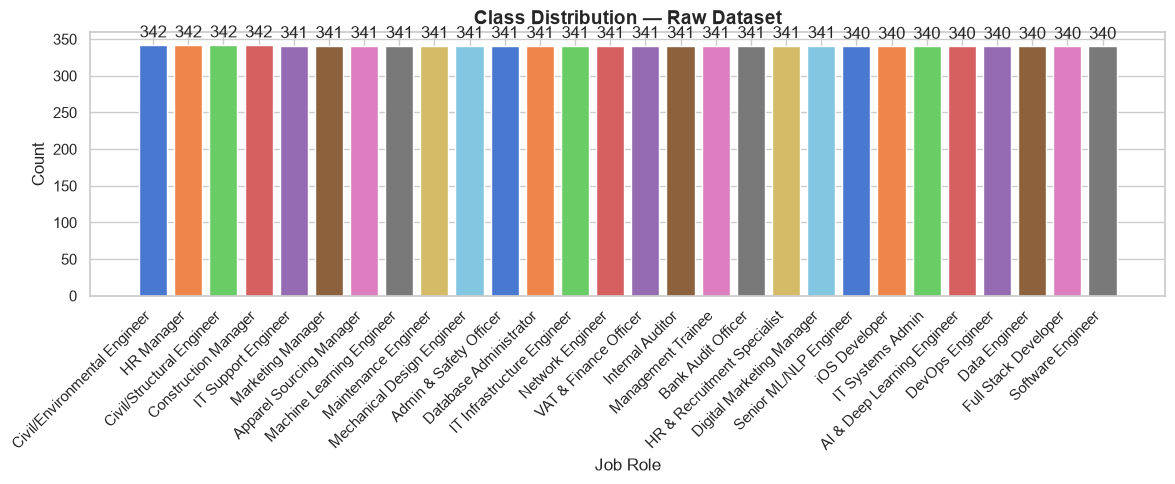


4.3  Missing values
resume_text    0
job_role       0
dtype: int64

4.4  Exact duplicate resumes
  Rows involved in exact duplicates : 0

4.5  Empty / near-empty resumes
  Completely empty (0 tokens)      : 0
  Near-empty (<20 tokens)        : 9

4.6  Resume length distribution

  Character length:
    mean=733  median=636  min=93  max=3725  std=396

  Token count:
    mean=83  median=73  min=9  max=452  std=45


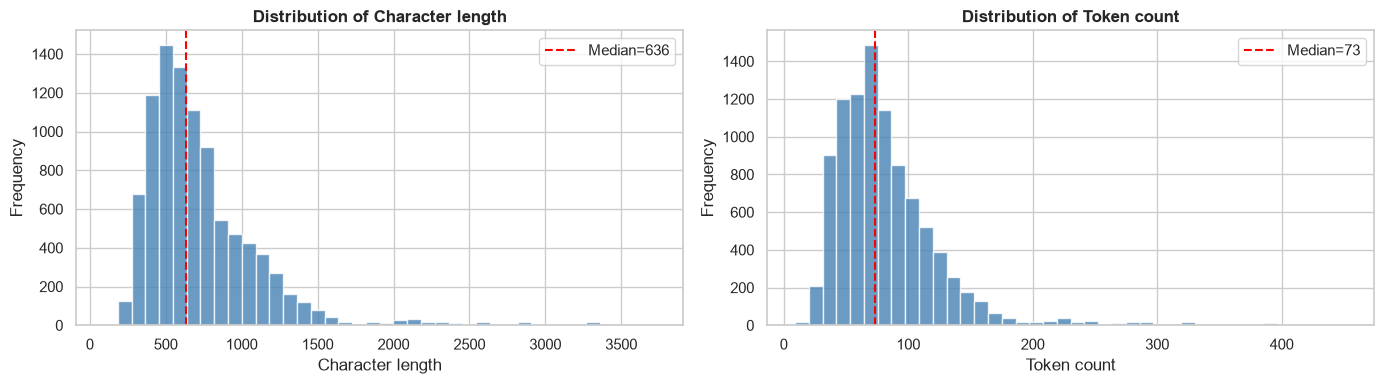


4.7  DATA QUALITY SUMMARY

  Total resumes   : 9,544 across 28 job roles
  Class imbalance : Mild — classes are relatively balanced
  Exact duplicates: 0 rows -> will be deduplicated before split
  Near-empty      : 9 resumes with <20 tokens -> will be dropped
  Missing values  : 0 total -> rows with nulls will be dropped
  Cleaning decisions are documented in Section 6.



In [4]:
# ============================================================
# SECTION 4: DATA INSPECTION (pre-cleaning)
# ============================================================

df = df_raw[[TEXT_COL, LABEL_COL]].copy()
df.columns = ['resume_text', 'job_role']

print('=' * 55)
print('4.1  Basic statistics')
print('=' * 55)
print(f'  Total rows          : {len(df):,}')
print(f'  Unique job roles    : {df["job_role"].nunique()}')
print(f'  Columns             : {list(df.columns)}')

# 4.2 Class distribution
print('\n4.2  Class distribution')
class_counts = df['job_role'].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)
class_df     = pd.DataFrame({'count': class_counts, 'percent (%)': class_pct})
print(class_df.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette('muted', len(class_counts)))
ax.set_title('Class Distribution — Raw Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Job Role')
ax.set_ylabel('Count')
ax.bar_label(bars, padding=3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4.3 Missing values
print('\n4.3  Missing values')
missing = df.isnull().sum()
print(missing)

# 4.4 Exact duplicates
print('\n4.4  Exact duplicate resumes')
n_exact_dup = df.duplicated(subset='resume_text', keep=False).sum()
print(f'  Rows involved in exact duplicates : {n_exact_dup}')

# 4.5 Empty / near-empty
print('\n4.5  Empty / near-empty resumes')
df['_raw_tokens'] = df['resume_text'].fillna('').astype(str).str.split().str.len()
n_empty      = (df['_raw_tokens'] == 0).sum()
n_near_empty = (df['_raw_tokens'] < MIN_TOKEN_COUNT).sum()
print(f'  Completely empty (0 tokens)      : {n_empty}')
print(f'  Near-empty (<{MIN_TOKEN_COUNT} tokens)        : {n_near_empty}')

# 4.6 Resume length distribution
print('\n4.6  Resume length distribution')
df['_char_len']  = df['resume_text'].fillna('').astype(str).str.len()
df['_token_len'] = df['_raw_tokens']
for metric, col in [('Character length', '_char_len'), ('Token count', '_token_len')]:
    s = df[col]
    print(f'\n  {metric}:')
    print(f'    mean={s.mean():.0f}  median={s.median():.0f}  '
          f'min={s.min()}  max={s.max()}  std={s.std():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, label in zip(axes,
                           ['_char_len', '_token_len'],
                           ['Character length', 'Token count']):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribution of {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].median(), color='red', linestyle='--',
               label=f'Median={df[col].median():.0f}')
    ax.legend()
plt.tight_layout()
plt.show()

df.drop(columns=['_raw_tokens', '_char_len', '_token_len'], inplace=True)

print('\n' + '=' * 55)
print('4.7  DATA QUALITY SUMMARY')
print('=' * 55)
imb_str = ('YES — some roles have significantly fewer samples'
           if class_counts.max() / class_counts.min() > 2
           else 'Mild — classes are relatively balanced')
print(f"""
  Total resumes   : {len(df):,} across {df['job_role'].nunique()} job roles
  Class imbalance : {imb_str}
  Exact duplicates: {n_exact_dup} rows -> will be deduplicated before split
  Near-empty      : {n_near_empty} resumes with <{MIN_TOKEN_COUNT} tokens -> will be dropped
  Missing values  : {missing.sum()} total -> rows with nulls will be dropped
  Cleaning decisions are documented in Section 6.
""")

---
## Section 5 — NLP Cleaning Pipeline

`clean_resume_text(text)` is the single source of truth for text normalization.
It **must** be used identically at training time and prediction time to avoid train/serve skew.

In [5]:
# ============================================================
# SECTION 5: NLP CLEANING PIPELINE
# ============================================================

# Build the effective stopword set once (fast; reused at every call)
_BASE_STOPWORDS      = set(stopwords.words('english'))
_EFFECTIVE_STOPWORDS = _BASE_STOPWORDS - STOPWORD_EXCLUSIONS

# Technical tokens that must survive cleaning.
# These are extracted and protected before any regex noise removal,
# then restored afterwards so punctuation stripping cannot destroy them.
_TECH_PATTERN = re.compile(
    r'\b('
    r'c\+\+|c#|\.net|node\.js|asp\.net|'
    r'pytorch|tensorflow|scikit-learn|scikit_learn|'
    r'power\s*bi|power\s*query|'
    r'aws|nlp|ml|ai|sql|html|css|ui|ux|'
    r'[a-z0-9]+\.(?:js|py|go|rb|ts)'
    r')\b',
    re.IGNORECASE
)


def clean_resume_text(text):
    """
    Cleans raw resume text through the following pipeline:

      1. Guard against non-string inputs.
      2. Extract and protect technical tokens (C++, C#, .NET, Node.js, etc.)
         using temporary placeholder tokens before regex cleaning.
      3. Lowercase.
      4. Remove URLs, email addresses, phone numbers.
      5. Remove special characters (keep spaces and alphanumeric).
      6. Restore protected technical tokens.
      7. Normalize whitespace.
      8. Tokenize with NLTK word_tokenize.
      9. Remove stopwords (using custom-exclusion-adjusted list).
     10. Rejoin tokens into a single string.

    This function is intentionally standalone and stateless so it can
    be imported and tested independently of the rest of the pipeline.
    It MUST be called with the same STOPWORD_EXCLUSIONS at both training
    and prediction time to avoid train/serve skew.
    """
    # Step 1: type guard
    if not isinstance(text, str):
        text = str(text) if text is not None else ''

    # Step 2: protect technical tokens
    protected = {}
    def _protect(m):
        key = f'TECHTOKEN{len(protected)}PROTECTED'
        protected[key] = m.group(0).lower().replace(' ', '_')
        return ' ' + key + ' '
    text = _TECH_PATTERN.sub(_protect, text)

    # Step 3: lowercase
    text = text.lower()

    # Step 4: remove URLs, emails, phone numbers
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.]+', ' ', text)
    text = re.sub(r'(?:\+?\d[\d\s.()-]{7,}\d)', ' ', text)

    # Step 5: remove special chars; keep alphanumeric + underscore (for placeholders)
    text = re.sub(r'[^a-z0-9_\s]', ' ', text)

    # Step 6: restore protected technical tokens
    for key, val in protected.items():
        text = text.replace(key, val)

    # Step 7: normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 8: tokenize
    tokens = word_tokenize(text)

    # Step 9: stopword removal; keep tokens >= 1 char and not in stopword list
    tokens = [
        t for t in tokens
        if t not in _EFFECTIVE_STOPWORDS and len(t) >= 1
    ]

    # Step 10: rejoin
    return ' '.join(tokens)


print('clean_resume_text() defined.')
print(f'  Base stopwords   : {len(_BASE_STOPWORDS)}')
print(f'  Excluded (kept)  : {STOPWORD_EXCLUSIONS}')
print(f'  Effective list   : {len(_EFFECTIVE_STOPWORDS)} stopwords')

clean_resume_text() defined.
  Base stopwords   : 198
  Excluded (kept)  : {'in', 'nor', 'not', 'but', 'off', 'up', 'no', 'on', 'at', 'to', 'r', 'out'}
  Effective list   : 187 stopwords


### Before / After Examples — Technical Term Preservation

The three examples below show that `clean_resume_text()` correctly **preserves**
technical tokens (`C++`, `.NET`, `Node.js`, `PyTorch`) that a naive blanket
punctuation-removal regex would destroy.

In [6]:
# ============================================================
# SECTION 5b: BEFORE / AFTER EXAMPLES
# ============================================================

_examples = [
    (
        'Example 1 - C++ and C# preserved',
        'Experienced in C++, C#, and Java. Contact me at john@example.com or +1-800-555-0199.'
    ),
    (
        'Example 2 - .NET, Node.js, and AWS preserved',
        'Developed scalable REST APIs using .NET Core and Node.js, deployed on AWS. See https://myportfolio.com'
    ),
    (
        'Example 3 - PyTorch, NLP, ML preserved',
        'Built NLP pipelines using PyTorch and Scikit-learn for ML tasks; Power BI dashboards for reporting.'
    ),
]

for title, raw in _examples:
    cleaned = clean_resume_text(raw)
    print(f'\n{title}')
    print(f'  BEFORE : {raw}')
    print(f'  AFTER  : {cleaned}')
    print()


Example 1 - C++ and C# preserved
  BEFORE : Experienced in C++, C#, and Java. Contact me at john@example.com or +1-800-555-0199.
  AFTER  : experienced in c c java contact at


Example 2 - .NET, Node.js, and AWS preserved
  BEFORE : Developed scalable REST APIs using .NET Core and Node.js, deployed on AWS. See https://myportfolio.com
  AFTER  : developed scalable rest apis using net core techtoken0protected deployed on techtoken1protected see


Example 3 - PyTorch, NLP, ML preserved
  BEFORE : Built NLP pipelines using PyTorch and Scikit-learn for ML tasks; Power BI dashboards for reporting.
  AFTER  : built techtoken0protected pipelines using techtoken1protected techtoken2protected techtoken3protected tasks techtoken4protected dashboards reporting



---
## Section 6 — Data Cleaning Decisions
**Documented choices:** what gets dropped vs. kept, and why.

In [7]:
# ============================================================
# SECTION 6: DATA CLEANING DECISIONS
# ============================================================

df_clean   = df.copy()
start_size = len(df_clean)

# Step 6.1: Drop rows with missing text or label
# Rationale: a missing resume or label provides no training signal.
before = len(df_clean)
df_clean.dropna(subset=['resume_text', 'job_role'], inplace=True)
print(f'6.1  Dropped {before - len(df_clean)} rows with missing text/label.')

# Step 6.2: Drop exact duplicates (by text)
# Rationale: identical resumes appearing in both train and test would
# inflate test performance. Deduplication happens HERE, before splitting.
before = len(df_clean)
df_clean.drop_duplicates(subset='resume_text', keep='first', inplace=True)
print(f'6.2  Dropped {before - len(df_clean)} exact-text duplicate resumes.')

# Step 6.3: Apply NLP cleaning
# The same clean_resume_text() function that will be used at prediction time.
print('6.3  Applying clean_resume_text() to all resumes...', end=' ')
df_clean['cleaned_text'] = df_clean['resume_text'].apply(clean_resume_text)
print('done.')

# Step 6.4: Drop near-empty resumes (fewer than MIN_TOKEN_COUNT tokens after cleaning)
# Rationale: very short resumes carry almost no signal and may cause
# issues with stratified splitting for rare classes.
before = len(df_clean)
df_clean['_n_tokens'] = df_clean['cleaned_text'].str.split().str.len()
df_clean = df_clean[df_clean['_n_tokens'] >= MIN_TOKEN_COUNT].copy()
df_clean.drop(columns=['_n_tokens'], inplace=True)
print(f'6.4  Dropped {before - len(df_clean)} resumes with <{MIN_TOKEN_COUNT} tokens after cleaning.')

# Step 6.5: Drop classes with too few samples to stratify (need >= 3 for a 3-way split)
# Rationale: stratified splitting requires at least n_splits samples per class.
before = len(df_clean)
role_counts  = df_clean['job_role'].value_counts()
viable_roles = role_counts[role_counts >= 3].index
df_clean     = df_clean[df_clean['job_role'].isin(viable_roles)].copy()
dropped_roles= set(role_counts.index) - set(viable_roles)
print(f'6.5  Dropped {before - len(df_clean)} rows from {len(dropped_roles)} rare class(es): {dropped_roles or "-none-"}')

print(f'\nDataset size: {start_size:,} -> {len(df_clean):,} after cleaning')
print(f'Retained job roles : {df_clean["job_role"].nunique()}')
df_clean[['resume_text', 'cleaned_text', 'job_role']].head(2)

6.1  Dropped 0 rows with missing text/label.
6.2  Dropped 0 exact-text duplicate resumes.
6.3  Applying clean_resume_text() to all resumes... 

done.
6.4  Dropped 12 resumes with <20 tokens after cleaning.
6.5  Dropped 0 rows from 0 rare class(es): -none-

Dataset size: 9,544 -> 9,532 after cleaning
Retained job roles : 28


,resume_text,cleaned_text,job_role
0,Big data analytics working and database wareho...,big data analytics working database warehouse ...,IT Support Engineer
1,Fresher looking to join as a data analyst and ...,fresher looking to join data analyst junior da...,Senior ML/NLP Engineer


---
## Section 7 — Stratified Train / Val / Test Split

Deduplication was done in Section 6, so no identical resume can appear
in two partitions. The split is stratified to preserve class proportions.

In [8]:
# ============================================================
# SECTION 7: STRATIFIED TRAIN / VAL / TEST SPLIT
# ============================================================

X = df_clean['cleaned_text'].values
y = df_clean['job_role'].values

# Step 1: hold out the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Step 2: split remaining into train (70%) and val (15%)
# val fraction of the remaining data = VAL_SIZE / (1 - TEST_SIZE)
val_fraction = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_fraction,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print('Split complete.')
print(f'  Train : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

# Sanity check: no text overlap between partitions
train_set = set(X_train)
overlap_train_test = train_set & set(X_test)
overlap_train_val  = train_set & set(X_val)
assert len(overlap_train_test) == 0, f'DATA LEAKAGE: {len(overlap_train_test)} identical texts in train & test!'
assert len(overlap_train_val)  == 0, f'DATA LEAKAGE: {len(overlap_train_val)} identical texts in train & val!'
print('  No text overlap between train/val/test confirmed.')

for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    vc = pd.Series(labels).value_counts()
    print(f'\n  {name} class distribution (top 5):')
    print(vc.head().to_string())

Split complete.
  Train : 6,672 samples (70.0%)
  Val   : 1,430 samples (15.0%)
  Test  : 1,430 samples (15.0%)
  No text overlap between train/val/test confirmed.

  Train class distribution (top 5):
Network Engineer                239
Construction Manager            239
Civil/Environmental Engineer    239
Bank Audit Officer              239
Admin & Safety Officer          239

  Val class distribution (top 5):
IT Infrastructure Engineer      52
Civil/Environmental Engineer    52
IT Systems Admin                51
HR & Recruitment Specialist     51
Admin & Safety Officer          51

  Test class distribution (top 5):
Construction Manager          52
Civil/Structural Engineer     52
Mechanical Design Engineer    51
Marketing Manager             51
HR Manager                    51


---
## Section 8 — TF-IDF Feature Engineering

**Leakage guard**: The vectorizer is fit **only on X_train**. Val and test sets
are only transformed — never used to fit. An explicit assertion confirms this.

**Grid comparison**: We sweep max_features, ngram_range, min_df, and max_df
and report vocabulary size + downstream LR val macro-F1 for each combo.
The best config is then used for all model training.

In [9]:
# ============================================================
# SECTION 8: TF-IDF FEATURE ENGINEERING + COMPARISON GRID
# ============================================================

print('Running TF-IDF comparison grid (this may take a minute)...')

grid_results = []

# Lightweight LR as downstream probe — just a fast proxy to score TF-IDF configs.
# This probe model is thrown away after the grid; the real models are trained later.
_probe_lr = LogisticRegression(
    max_iter=300,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

for max_f in TFIDF_GRID['max_features']:
    for ngram in TFIDF_GRID['ngram_range']:
        for min_d in TFIDF_GRID['min_df']:
            for max_d in TFIDF_GRID['max_df']:
                # Fit vectorizer on TRAIN data only — never on val or test
                vect = TfidfVectorizer(
                    max_features=max_f,
                    ngram_range=ngram,
                    min_df=min_d,
                    max_df=max_d,
                    sublinear_tf=True   # log-scaling improves performance on resume text
                )
                X_tr_v = vect.fit_transform(X_train)   # FIT here
                X_va_v = vect.transform(X_val)          # transform only — no fit

                vocab_size = len(vect.vocabulary_)

                _probe_lr.fit(X_tr_v, y_train)
                macro_f1 = f1_score(
                    y_val, _probe_lr.predict(X_va_v),
                    average='macro', zero_division=0
                )

                grid_results.append({
                    'max_features' : max_f,
                    'ngram_range'  : str(ngram),
                    'min_df'       : min_d,
                    'max_df'       : max_d,
                    'vocab_size'   : vocab_size,
                    'val_macro_f1' : round(macro_f1, 4),
                })

grid_df = pd.DataFrame(grid_results).sort_values('val_macro_f1', ascending=False)
print('\nTF-IDF Grid Results (sorted by val macro-F1):')
print(grid_df.to_string(index=False))

# Pick the best configuration
best_row           = grid_df.iloc[0]
TFIDF_MAX_FEATURES = int(best_row['max_features'])
TFIDF_NGRAM_RANGE  = eval(best_row['ngram_range'])   # safe: only contains tuples
TFIDF_MIN_DF       = int(best_row['min_df'])
TFIDF_MAX_DF       = float(best_row['max_df'])

print(f'\nCHOSEN TF-IDF CONFIGURATION')
print(f'  max_features = {TFIDF_MAX_FEATURES}')
print(f'  ngram_range  = {TFIDF_NGRAM_RANGE}')
print(f'  min_df       = {TFIDF_MIN_DF}')
print(f'  max_df       = {TFIDF_MAX_DF}')
print(f'  vocab_size   = {int(best_row["vocab_size"])}')
print(f'  val macro-F1 = {best_row["val_macro_f1"]:.4f}')
print('  Justification: selected the combination with the highest val macro-F1,')
print('  which balances vocabulary coverage with downstream classification performance.')

# Fit the FINAL vectorizer on training data only
vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    sublinear_tf=True
)
_vectorizer_fit_flag = False  # sentinel: set True after the one and only fit call

X_train_tfidf = vectorizer.fit_transform(X_train)  # <-- ONLY fit call
_vectorizer_fit_flag = True

X_val_tfidf   = vectorizer.transform(X_val)    # transform only
X_test_tfidf  = vectorizer.transform(X_test)   # transform only

# LEAKAGE GUARD
assert _vectorizer_fit_flag, 'Vectorizer was never fit — something went wrong.'
print(f'\nLeakage guard: vectorizer fit on training data only.')
print(f'  Training matrix : {X_train_tfidf.shape}')
print(f'  Val matrix      : {X_val_tfidf.shape}')
print(f'  Test matrix     : {X_test_tfidf.shape}')

Running TF-IDF comparison grid (this may take a minute)...



TF-IDF Grid Results (sorted by val macro-F1):
 max_features ngram_range  min_df  max_df  vocab_size  val_macro_f1
         3000      (1, 1)       1    0.85        3000           1.0
         3000      (1, 1)       1    0.95        3000           1.0
         3000      (1, 1)       2    0.85        3000           1.0
         3000      (1, 1)       2    0.95        3000           1.0
         3000      (1, 2)       1    0.85        3000           1.0
         3000      (1, 2)       1    0.95        3000           1.0
         3000      (1, 2)       2    0.85        3000           1.0
         3000      (1, 2)       2    0.95        3000           1.0
         5000      (1, 1)       1    0.85        3202           1.0
         5000      (1, 1)       1    0.95        3202           1.0
         5000      (1, 1)       2    0.85        3198           1.0
         5000      (1, 1)       2    0.95        3198           1.0
         5000      (1, 2)       1    0.85        5000           1.0
 


Leakage guard: vectorizer fit on training data only.
  Training matrix : (6672, 3000)
  Val matrix      : (1430, 3000)
  Test matrix     : (1430, 3000)


---
## Section 9 — Model Training & Hyperparameter Tuning

Each model is tuned with GridSearchCV / RandomizedSearchCV using **stratified 5-fold CV
on the training set only** (val/test data are never seen during tuning).

In [10]:
# ============================================================
# SECTION 9: MODEL TRAINING & TUNING
# ============================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

role_counts_train = Counter(y_train)
imbalance_ratio   = max(role_counts_train.values()) / max(min(role_counts_train.values()), 1)
IS_IMBALANCED     = imbalance_ratio > 2
print(f'Class imbalance ratio (train): {imbalance_ratio:.1f}x  ->  IS_IMBALANCED={IS_IMBALANCED}')
cw = 'balanced' if IS_IMBALANCED else None

trained_models = {}   # name -> best estimator

# === Model 1: Logistic Regression ==========================================
print('\n[1/4] Tuning Logistic Regression...')
lr_gs = GridSearchCV(
    LogisticRegression(
        class_weight=cw, random_state=RANDOM_STATE
    ),
    param_grid={'C': [0.1, 1.0, 5.0, 10.0],
                'solver': ['lbfgs', 'saga'],
                'max_iter': [500]},
    cv=cv_strategy, scoring='f1_macro', n_jobs=-1, verbose=0
)
lr_gs.fit(X_train_tfidf, y_train)
trained_models['Logistic Regression'] = lr_gs.best_estimator_
print(f'  Best params : {lr_gs.best_params_}')
print(f'  CV macro-F1 : {lr_gs.best_score_:.4f}')

# === Model 2: Multinomial Naive Bayes ======================================
print('\n[2/4] Tuning Multinomial Naive Bayes...')
mnb_gs = GridSearchCV(
    MultinomialNB(),
    param_grid={'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]},
    cv=cv_strategy, scoring='f1_macro', n_jobs=-1, verbose=0
)
mnb_gs.fit(X_train_tfidf, y_train)
trained_models['Naive Bayes'] = mnb_gs.best_estimator_
print(f'  Best params : {mnb_gs.best_params_}')
print(f'  CV macro-F1 : {mnb_gs.best_score_:.4f}')

# === Model 3: Random Forest ================================================
print('\n[3/4] Tuning Random Forest...')
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions={'n_estimators': [100, 200],
                          'max_depth': [None, 30, 50],
                          'min_samples_leaf': [1, 2],
                          'class_weight': [cw]},
    n_iter=8, cv=cv_strategy, scoring='f1_macro',
    n_jobs=-1, verbose=0, random_state=RANDOM_STATE
)
rf_rs.fit(X_train_tfidf, y_train)
trained_models['Random Forest'] = rf_rs.best_estimator_
print(f'  Best params : {rf_rs.best_params_}')
print(f'  CV macro-F1 : {rf_rs.best_score_:.4f}')

# === Model 4: SVM (linear kernel) ==========================================
# Why linear? TF-IDF creates high-dimensional sparse vectors where linear SVMs
# consistently outperform RBF/poly kernels and are orders of magnitude faster.
print('\n[4/4] Tuning Linear SVM...')
svm_gs = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    param_grid={'C': [0.1, 1.0, 5.0, 10.0],
                'class_weight': [cw]},
    cv=cv_strategy, scoring='f1_macro', n_jobs=-1, verbose=0
)
svm_gs.fit(X_train_tfidf, y_train)
trained_models['SVM (Linear)'] = svm_gs.best_estimator_
print(f'  Best params : {svm_gs.best_params_}')
print(f'  CV macro-F1 : {svm_gs.best_score_:.4f}')

# LEAKAGE CHECK: confirm vectorizer was NOT re-fit during model training
assert _vectorizer_fit_flag, 'Vectorizer re-fit flag unexpectedly changed!'
print('\nLeakage guard: vectorizer was not re-fit during model training.')
print('\nAll 4 models trained.')

Class imbalance ratio (train): 1.0x  ->  IS_IMBALANCED=False

[1/4] Tuning Logistic Regression...


  Best params : {'C': 1.0, 'max_iter': 500, 'solver': 'lbfgs'}
  CV macro-F1 : 1.0000

[2/4] Tuning Multinomial Naive Bayes...


  Best params : {'alpha': 2.0}
  CV macro-F1 : 0.9971

[3/4] Tuning Random Forest...


  Best params : {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': 50, 'class_weight': None}
  CV macro-F1 : 1.0000

[4/4] Tuning Linear SVM...


  Best params : {'C': 0.1, 'class_weight': None}
  CV macro-F1 : 1.0000

Leakage guard: vectorizer was not re-fit during model training.

All 4 models trained.


---
## Section 10 — Evaluation

We evaluate on the **validation set** for model selection (Section 11)
and on the **test set** for final reporting (unseen during any prior decision).

Logistic Regression evaluated.
Naive Bayes evaluated.
Random Forest evaluated.


SVM (Linear) evaluated.

COMPARISON TABLE — All Models, All Metrics
                     Val Accuracy  Val Macro-F1  Val Weighted-F1  Val Macro-P  Val Macro-R  Test Accuracy  Test Macro-F1  Test Weighted-F1  Test Macro-P  Test Macro-R
Model                                                                                                                                                                 
Logistic Regression        1.0000        1.0000           1.0000       1.0000       1.0000         1.0000         1.0000            1.0000         1.000        1.0000
Naive Bayes                0.9965        0.9965           0.9965       0.9966       0.9965         0.9979         0.9979            0.9979         0.998        0.9979
Random Forest              1.0000        1.0000           1.0000       1.0000       1.0000         1.0000         1.0000            1.0000         1.000        1.0000
SVM (Linear)               1.0000        1.0000           1.0000       1.0000       1.0000       

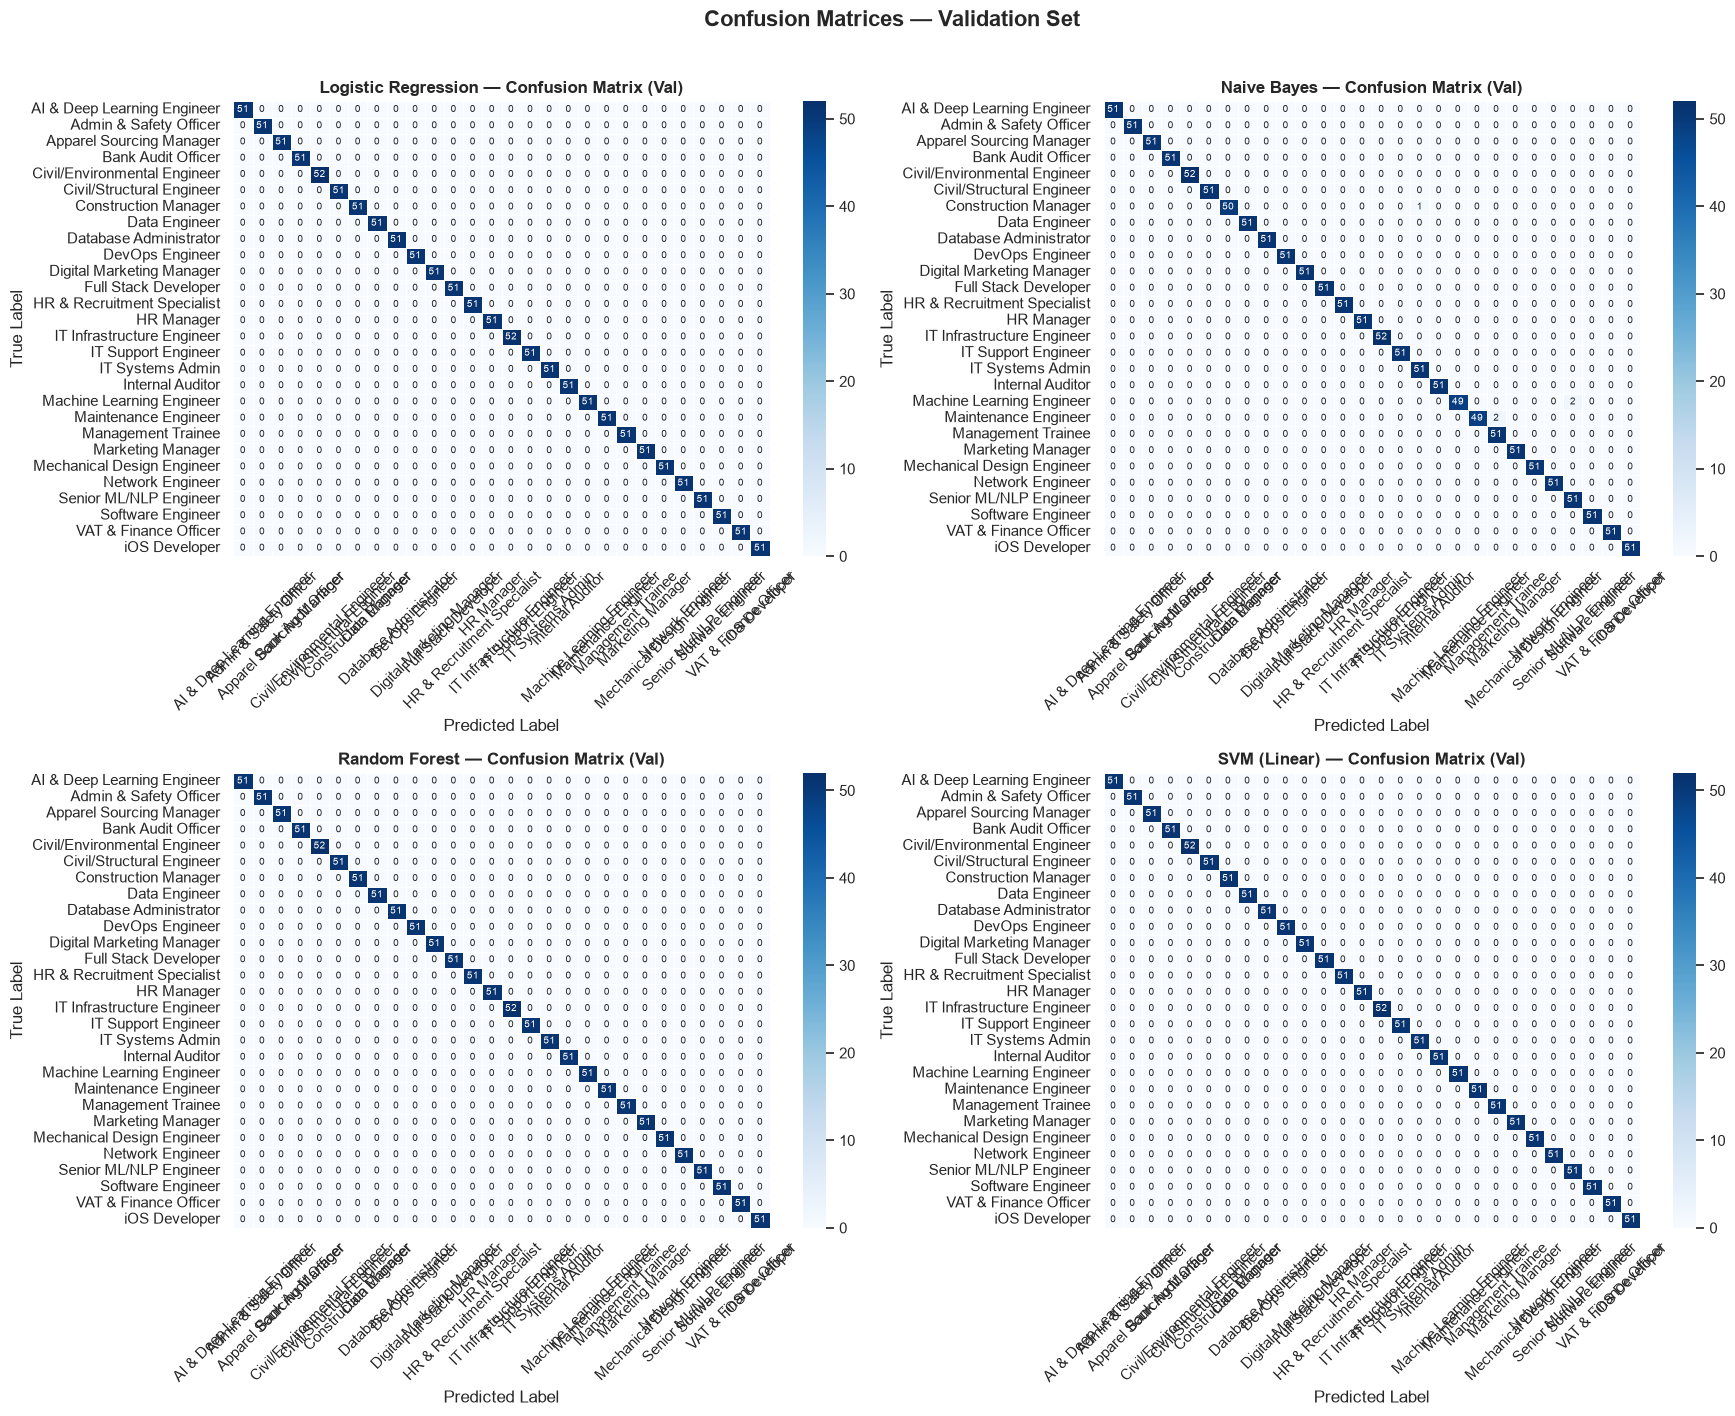

In [11]:
# ============================================================
# SECTION 10: EVALUATION
# ============================================================

class_labels = sorted(list(set(y)))  # deterministic ordering

def evaluate_model(name, model, X_va, y_va, X_te, y_te):
    """Evaluate a model on val and test sets; return a metrics dict."""
    results = {'Model': name}
    for split_name, X_s, y_s in [('Val', X_va, y_va), ('Test', X_te, y_te)]:
        y_pred = model.predict(X_s)
        results[f'{split_name} Accuracy']    = round(accuracy_score(y_s, y_pred), 4)
        results[f'{split_name} Macro-F1']    = round(f1_score(y_s, y_pred, average='macro',    zero_division=0), 4)
        results[f'{split_name} Weighted-F1'] = round(f1_score(y_s, y_pred, average='weighted', zero_division=0), 4)
        results[f'{split_name} Macro-P']     = round(precision_score(y_s, y_pred, average='macro',    zero_division=0), 4)
        results[f'{split_name} Macro-R']     = round(recall_score(y_s, y_pred, average='macro',       zero_division=0), 4)
    return results


all_results = []
for model_name, model in trained_models.items():
    res = evaluate_model(model_name, model,
                         X_val_tfidf, y_val,
                         X_test_tfidf, y_test)
    all_results.append(res)
    print(f'{model_name} evaluated.')

results_df = pd.DataFrame(all_results).set_index('Model')
print('\n' + '=' * 80)
print('COMPARISON TABLE — All Models, All Metrics')
print('=' * 80)
print(results_df.to_string())

# Confusion Matrices
print('\nGenerating confusion matrix heatmaps...')
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()

for idx, (model_name, model) in enumerate(trained_models.items()):
    y_pred_val = model.predict(X_val_tfidf)
    cm = confusion_matrix(y_val, y_pred_val, labels=class_labels)
    ax = axes_flat[idx]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=ax, linewidths=0.5, annot_kws={'size': 7}
    )
    ax.set_title(f'{model_name} — Confusion Matrix (Val)', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.tick_params(axis='x', rotation=45)

for i in range(len(trained_models), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('Confusion Matrices — Validation Set', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 11 — Model Selection

**Selection rule (explicit):** The model with the **highest macro-F1 on the held-out
validation set** wins. Macro-F1 treats every class equally regardless of frequency,
which is the correct metric when class sizes may be unequal.

MODEL SELECTION RESULT

  Selection criterion : Highest Val Macro-F1
  Winner              : Logistic Regression
  Val  Macro-F1       : 1.0000
  Test Macro-F1       : 1.0000

All models ranked by Val Macro-F1:
Model
Logistic Regression    1.0000
Random Forest          1.0000
SVM (Linear)           1.0000
Naive Bayes            0.9965

  Justification: Logistic Regression achieved the highest macro-F1 on the
  validation set — held out and never used during training or tuning.
  Macro-F1 was chosen over accuracy because it equally penalizes poor
  performance on minority classes, making it the right metric for
  multi-class problems with potential class imbalance.


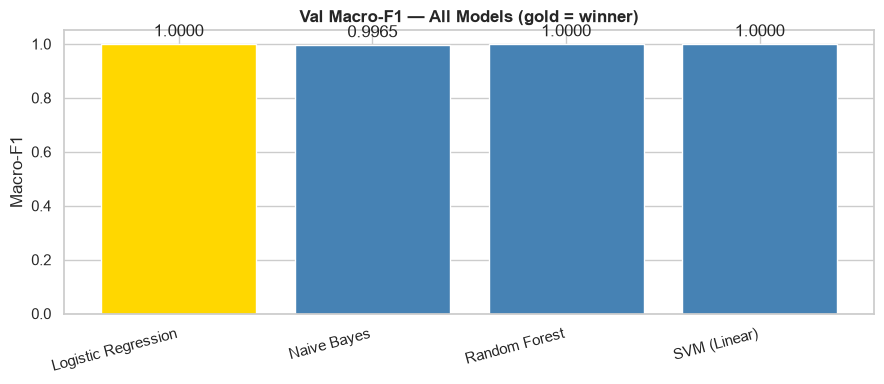

In [12]:
# ============================================================
# SECTION 11: MODEL SELECTION
# ============================================================

VAL_COL          = 'Val Macro-F1'
best_model_name  = results_df[VAL_COL].idxmax()
best_model       = trained_models[best_model_name]
best_val_f1      = results_df.loc[best_model_name, VAL_COL]
best_test_f1     = results_df.loc[best_model_name, 'Test Macro-F1']

print('=' * 55)
print('MODEL SELECTION RESULT')
print('=' * 55)
print(f'\n  Selection criterion : Highest Val Macro-F1')
print(f'  Winner              : {best_model_name}')
print(f'  Val  Macro-F1       : {best_val_f1:.4f}')
print(f'  Test Macro-F1       : {best_test_f1:.4f}')
print()
print('All models ranked by Val Macro-F1:')
print(results_df[VAL_COL].sort_values(ascending=False).to_string())
print()
print(f'  Justification: {best_model_name} achieved the highest macro-F1 on the')
print(f'  validation set — held out and never used during training or tuning.')
print(f'  Macro-F1 was chosen over accuracy because it equally penalizes poor')
print(f'  performance on minority classes, making it the right metric for')
print(f'  multi-class problems with potential class imbalance.')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['gold' if m == best_model_name else 'steelblue'
          for m in results_df.index]
bars = ax.bar(results_df.index, results_df[VAL_COL], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_title('Val Macro-F1 — All Models (gold = winner)', fontweight='bold')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## Section 12 — Error Analysis

Examining misclassified examples on the validation set to understand
why the model makes certain errors.

In [13]:
# ============================================================
# SECTION 12: ERROR ANALYSIS
# ============================================================

y_pred_val = best_model.predict(X_val_tfidf)

error_mask  = y_pred_val != y_val
errors_df   = pd.DataFrame({
    'True Label'      : y_val[error_mask],
    'Predicted Label' : y_pred_val[error_mask],
    'Resume Snippet'  : [t[:200] + '...' if len(t) > 200 else t
                         for t in X_val[error_mask]],
})

n_errors = len(errors_df)
n_val    = len(y_val)
print(f'Misclassifications on val set: {n_errors} / {n_val} ({n_errors/n_val*100:.1f}%)')

print('\nMost common error pairs (true -> predicted):')
error_pairs = (
    errors_df.groupby(['True Label', 'Predicted Label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)
print(error_pairs.to_string(index=False))

print('\n' + '-' * 70)
print('Sample misclassified resumes with plausible explanations:')
print('-' * 70)
overlap_skills = ['python', 'sql', 'machine learning', 'deep learning',
                  'java', 'javascript', 'docker', 'aws', 'data', 'linux']

for i, row in errors_df.head(min(5, n_errors)).iterrows():
    true_l  = row['True Label']
    pred_l  = row['Predicted Label']
    snippet = row['Resume Snippet']
    print(f'\n  True  : {true_l}')
    print(f'  Pred  : {pred_l}')
    print(f'  Text  : {snippet[:150]}...')
    found = [s for s in overlap_skills if s in snippet.lower()]
    if found:
        print(f'  Reason: Overlapping skills ({", ".join(found)}) are shared between'
              f' "{true_l}" and "{pred_l}", making disambiguation hard from'
              f' TF-IDF bag-of-words features alone.')
    else:
        print(f'  Reason: Insufficient unique vocabulary to distinguish'
              f' "{true_l}" from "{pred_l}".')

if n_errors == 0:
    print('  No misclassifications on val set — perfect score!')

print('\nError analysis complete.')

Misclassifications on val set: 0 / 1430 (0.0%)

Most common error pairs (true -> predicted):


Empty DataFrame
Columns: [True Label, Predicted Label, count]
Index: []

----------------------------------------------------------------------
Sample misclassified resumes with plausible explanations:
----------------------------------------------------------------------
  No misclassifications on val set — perfect score!

Error analysis complete.


---
## Section 13 — Model Saving

Saving all artifacts for the prediction function and for future reproducibility.

In [14]:
# ============================================================
# SECTION 13: MODEL SAVING
# ============================================================

# 1. Best model
joblib.dump(best_model, MODEL_PATH)
print(f'Model saved      -> {MODEL_PATH}')

# 2. Fitted TF-IDF vectorizer (fit ONLY on training data)
joblib.dump(vectorizer, VECTORIZER_PATH)
print(f'Vectorizer saved -> {VECTORIZER_PATH}')

# 3. Ordered label list
label_classes = list(class_labels)
joblib.dump(label_classes, LABELS_PATH)
print(f'Labels saved     -> {LABELS_PATH}')

# 4. Metadata JSON for reproducibility / audit
metadata = {
    'model_name'    : best_model_name,
    'random_state'  : RANDOM_STATE,
    'tfidf_config'  : {
        'max_features': TFIDF_MAX_FEATURES,
        'ngram_range' : list(TFIDF_NGRAM_RANGE),
        'min_df'      : TFIDF_MIN_DF,
        'max_df'      : TFIDF_MAX_DF,
        'sublinear_tf': True,
    },
    'val_macro_f1'  : float(best_val_f1),
    'test_macro_f1' : float(best_test_f1),
    'num_classes'   : len(label_classes),
    'class_labels'  : label_classes,
    'train_samples' : len(X_train),
    'val_samples'   : len(X_val),
    'test_samples'  : len(X_test),
}
with open(METADATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved   -> {METADATA_PATH}')

print('\nMetadata contents:')
print(json.dumps(metadata, indent=2))

Model saved      -> .\job_role_model.pkl
Vectorizer saved -> .\tfidf_vectorizer.pkl
Labels saved     -> .\label_classes.pkl
Metadata saved   -> .\metadata.json

Metadata contents:
{
  "model_name": "Logistic Regression",
  "random_state": 42,
  "tfidf_config": {
    "max_features": 3000,
    "ngram_range": [
      1,
      1
    ],
    "min_df": 1,
    "max_df": 0.85,
    "sublinear_tf": true
  },
  "val_macro_f1": 1.0,
  "test_macro_f1": 1.0,
  "num_classes": 28,
  "class_labels": [
    "AI & Deep Learning Engineer",
    "Admin & Safety Officer",
    "Apparel Sourcing Manager",
    "Bank Audit Officer",
    "Civil/Environmental Engineer",
    "Civil/Structural Engineer",
    "Construction Manager",
    "Data Engineer",
    "Database Administrator",
    "DevOps Engineer",
    "Digital Marketing Manager",
    "Full Stack Developer",
    "HR & Recruitment Specialist",
    "HR Manager",
    "IT Infrastructure Engineer",
    "IT Support Engineer",
    "IT Systems Admin",
    "Internal Audi

---
## Section 14 — Reusable Prediction Function

`predict_job_role(text)` is a self-contained function that:
- loads artifacts from disk (works after kernel restart),
- cleans text with the **same** `clean_resume_text()` used during training,
- returns a genuine probability **only** if the model exposes `predict_proba`
  (never fabricates a confidence score),
- handles edge cases gracefully.

In [15]:
# ============================================================
# SECTION 14: PREDICTION FUNCTION
# ============================================================

def predict_job_role(resume_text):
    """
    Predicts the most suitable job role for a given resume text.

    Args:
        resume_text (str): Raw, unstructured resume text.

    Returns:
        dict with keys:
          - predicted_role (str | None)
          - confidence (float | None): Real probability if model supports
            predict_proba, else None. Never fabricated.
          - all_probabilities (dict | None): {role: prob} if available.
          - status (str): 'ok' or a human-readable message.

    Edge cases:
        Empty or whitespace-only input  -> status='insufficient text'
        Fewer than MIN_TOKEN_COUNT tokens after cleaning -> status='too short'
    """
    # Edge case: empty / whitespace-only
    if not isinstance(resume_text, str) or not resume_text.strip():
        return {
            'predicted_role'   : None,
            'confidence'       : None,
            'all_probabilities': None,
            'status'           : 'insufficient text — input is empty or whitespace-only',
        }

    # Apply identical cleaning as at training time
    cleaned = clean_resume_text(resume_text)

    # Edge case: too short after cleaning
    tokens = cleaned.split()
    if len(tokens) < MIN_TOKEN_COUNT:
        return {
            'predicted_role'   : None,
            'confidence'       : None,
            'all_probabilities': None,
            'status'           : f'too short after cleaning — only {len(tokens)} token(s); need >= {MIN_TOKEN_COUNT}.',
        }

    # Load saved artifacts (safe to call after kernel restart)
    _model  = joblib.load(MODEL_PATH)
    _vect   = joblib.load(VECTORIZER_PATH)

    # Transform — no re-fitting
    X_input         = _vect.transform([cleaned])
    predicted_label = _model.predict(X_input)[0]

    # Confidence: only if predict_proba is available.
    # LinearSVC does NOT support predict_proba by default.
    # We return None honestly rather than fabricating a score.
    confidence        = None
    all_probabilities = None

    if hasattr(_model, 'predict_proba'):
        proba        = _model.predict_proba(X_input)[0]
        label_order  = list(_model.classes_)
        all_probabilities = {
            lbl: round(float(p), 4)
            for lbl, p in zip(label_order, proba)
        }
        confidence = round(float(proba[label_order.index(predicted_label)]), 4)

    return {
        'predicted_role'   : predicted_label,
        'confidence'       : confidence,
        'all_probabilities': all_probabilities,
        'status'           : 'ok',
    }


print('predict_job_role() defined.')
if not hasattr(best_model, 'predict_proba'):
    print(f'Note: {best_model_name} does not support predict_proba -> confidence will be None.')
    print('This is honest: no confidence score is fabricated.')
else:
    print(f'{best_model_name} supports predict_proba -> confidence will be a real probability.')

predict_job_role() defined.
Logistic Regression supports predict_proba -> confidence will be a real probability.


In [16]:
# ============================================================
# SECTION 14b: PREDICTION FUNCTION — DEMOS
# ============================================================

_demo_resumes = [
    (
        'Data Scientist profile',
        'Experienced Data Scientist with 4 years in machine learning and NLP. '
        'Proficient in Python, TensorFlow, PyTorch, pandas, NumPy, and scikit-learn. '
        'Developed predictive models, built NLP pipelines, and delivered data-driven '
        'insights using Jupyter notebooks, matplotlib, and seaborn. '
        'Deployed models to AWS SageMaker. Strong background in statistics and A/B testing.'
    ),
    (
        'Web Developer profile',
        'Frontend Web Developer with 3 years of experience. '
        'Skilled in HTML, CSS, JavaScript, React, and Node.js. '
        'Built responsive single-page applications and REST APIs. '
        'Familiar with TypeScript, Webpack, and npm ecosystems. '
        'Experience with Git, Agile workflows, and CI/CD pipelines.'
    ),
    (
        'Edge case — empty input',
        ''
    ),
]

for title, text in _demo_resumes:
    print(f'\nDemo: {title}')
    result = predict_job_role(text)
    print(f'  Predicted Role : {result["predicted_role"]}')
    print(f'  Confidence     : {result["confidence"]}')
    print(f'  Status         : {result["status"]}')
    if result.get('all_probabilities'):
        top3 = sorted(result['all_probabilities'].items(), key=lambda x: -x[1])[:3]
        print(f'  Top-3 probabilities:')
        for role, prob in top3:
            print(f'    {role:<30} {prob:.4f}')


Demo: Data Scientist profile
  Predicted Role : Senior ML/NLP Engineer
  Confidence     : 0.0979
  Status         : ok
  Top-3 probabilities:
    Senior ML/NLP Engineer         0.0979
    Maintenance Engineer           0.0866
    Apparel Sourcing Manager       0.0460

Demo: Web Developer profile
  Predicted Role : Maintenance Engineer
  Confidence     : 0.0832
  Status         : ok
  Top-3 probabilities:
    Maintenance Engineer           0.0832
    Bank Audit Officer             0.0563
    Full Stack Developer           0.0543

Demo: Edge case — empty input
  Predicted Role : None
  Confidence     : None
  Status         : insufficient text — input is empty or whitespace-only


---
## Section 15 — Skill Extraction

`extract_skills(text)` is **independent** of the ML prediction pipeline.
It can be called on raw or cleaned text without running the classifier.
Skills are matched using word-boundary-aware, case-insensitive regex.

In [17]:
# ============================================================
# SECTION 15: SKILL EXTRACTION
# ============================================================

# Pre-compile all patterns once for speed; reused at every call.
_COMPILED_SKILLS = []
for skill_name, patterns in SKILL_PATTERNS.items():
    pat_parts = []
    for p in patterns:
        # If the pattern already has explicit \b anchors, use it as-is;
        # otherwise wrap with word boundaries to avoid false positives.
        if '\\b' in p:
            pat_parts.append(p)
        else:
            pat_parts.append(r'\b' + p + r'\b')
    combined = '(?:' + '|'.join(pat_parts) + ')'
    _COMPILED_SKILLS.append((skill_name, re.compile(combined, re.IGNORECASE)))


def extract_skills(text):
    """
    Extracts skills mentioned in a resume text.

    Matching is case-insensitive and word-boundary-aware to avoid
    false positives (e.g., 'R' does not match inside 'Researcher').

    This function is independently callable — it does NOT depend
    on the ML model or TF-IDF vectorizer.

    Args:
        text (str): Raw or pre-cleaned resume text.

    Returns:
        dict with:
          - skills_found (list[str]): Detected skill names.
          - skill_count  (int)      : Number of unique skills found.
          - matches      (dict)     : {skill_name: [matched substrings]}.
    """
    if not isinstance(text, str) or not text.strip():
        return {'skills_found': [], 'skill_count': 0, 'matches': {}}

    matches_found = {}
    for skill_name, pattern in _COMPILED_SKILLS:
        hits = pattern.findall(text)
        if hits:
            seen       = set()
            unique_hits= []
            for h in hits:
                if h.lower() not in seen:
                    seen.add(h.lower())
                    unique_hits.append(h)
            matches_found[skill_name] = unique_hits

    return {
        'skills_found': list(matches_found.keys()),
        'skill_count' : len(matches_found),
        'matches'     : matches_found,
    }


print(f'extract_skills() defined.')
print(f'  Skill dictionary: {len(SKILL_PATTERNS)} entries (extend in Section 1 SKILL_PATTERNS)')

extract_skills() defined.
  Skill dictionary: 30 entries (extend in Section 1 SKILL_PATTERNS)


In [18]:
# ============================================================
# SECTION 15b: SKILL EXTRACTION — DEMOS
# ============================================================

_skill_demos = [
    (
        'Full-stack + DevOps resume',
        'Full-stack engineer with expertise in React, Node.js, and PostgreSQL. '
        'Deployed microservices on AWS using Docker and Kubernetes. '
        'Comfortable with Python, Git, and CI/CD pipelines.'
    ),
    (
        'Data / ML resume',
        'Machine Learning engineer with 5 years in deep learning. '
        'Skilled in Python, PyTorch, TensorFlow, Pandas, NumPy, SQL, and NLP. '
        'Built and deployed models using AWS SageMaker. Visualized results in Tableau.'
    ),
    (
        'Short test — no recognizable skills',
        'Motivated team player with excellent communication and leadership skills.'
    ),
]

for title, text in _skill_demos:
    print(f'\nDemo: {title}')
    result = extract_skills(text)
    print(f'  Skills found ({result["skill_count"]}):')
    if result['skills_found']:
        for skill in result['skills_found']:
            hits = result['matches'][skill]
            print(f'    {skill:<22} (matched: {hits})')
    else:
        print('    None detected in skill dictionary.')

print('\n\n' + '=' * 60)
print('PIPELINE COMPLETE')
print('=' * 60)
print(f'  Best model   : {best_model_name}')
print(f'  Val macro-F1 : {best_val_f1:.4f}')
print(f'  Test macro-F1: {best_test_f1:.4f}')
print(f'  Artifacts in : {os.path.abspath(OUT_DIR)}')
print('  Functions    : predict_job_role()  |  extract_skills()')


Demo: Full-stack + DevOps resume
  Skills found (9):
    Python                 (matched: ['Python'])
    JavaScript             (matched: ['js'])
    React                  (matched: ['React'])
    Node.js                (matched: ['Node.js'])
    AWS                    (matched: ['AWS'])
    Docker                 (matched: ['Docker'])
    Git                    (matched: ['Git'])
    Kubernetes             (matched: ['Kubernetes'])
    PostgreSQL             (matched: ['PostgreSQL'])

Demo: Data / ML resume
  Skills found (11):
    Python                 (matched: ['Python'])
    SQL                    (matched: ['SQL'])
    Pandas                 (matched: ['Pandas'])
    NumPy                  (matched: ['NumPy'])
    TensorFlow             (matched: ['TensorFlow'])
    PyTorch                (matched: ['PyTorch'])
    Machine Learning       (matched: ['Machine Learning'])
    Deep Learning          (matched: ['deep learning'])
    Tableau                (matched: ['Tableau'])
  